# Module 2, Part C — Regression: predicting `fare`

**Objective.** Build a multivariate **Linear Regression** model that predicts a
passenger's `fare` from the other relevant Titanic features. This notebook is kept
conceptually separate from the classification work in `02_classification.ipynb`:
here the **target is `fare`** (a continuous value), not `survived`.

**Data source.** `analytics/titanic.csv`, which was already saved once by the EDA
notebook (`01_eda.ipynb`). Titanic is **not** re-downloaded with seaborn here.

Pipeline:
1. Load `titanic.csv`.
2. Clean (consistent with the EDA / classification notebooks).
3. **Stratified train/test split before any preprocessing.**
4. sklearn `Pipeline` + `ColumnTransformer` (numeric: median impute + `StandardScaler`;
   categorical: most-frequent impute + `OneHotEncoder(drop="first")` — dropping the first
   level removes the multicollinearity that otherwise destabilises the linear model).
5. Fit `LinearRegression` and evaluate with MAE, RMSE, R², Adjusted R².
6. Residual analysis + heteroscedasticity diagnostic.

Reproducible via `random_state=42`.


In [1]:
import os, json
from pathlib import Path
# Normalise cwd to the repo root so paths resolve regardless of kernel launch dir.
if Path.cwd().name == "analytics":
    os.chdir("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

RANDOM_STATE = 42
OUT = Path("analytics/outputs")
OUT.mkdir(parents=True, exist_ok=True)
print("cwd:", Path.cwd(), "| outputs dir:", OUT)


cwd: C:\Users\Lenovo\Desktop\zepto-data-ai-platform | outputs dir: analytics\outputs


## 1. Load the saved dataset

Read `analytics/titanic.csv` directly (produced by the EDA notebook). No seaborn reload.


In [2]:
df = pd.read_csv("analytics/titanic.csv")
print("Loaded analytics/titanic.csv ->", df.shape)
print("Columns:", list(df.columns))
df.head()


Loaded analytics/titanic.csv -> (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Cleaning (consistent with the EDA / classification notebooks)

* Drop the 2 rows missing `embarked`/`embark_town`.
* Impute `age` with the median within each `(sex, pclass)` group (fallback overall median).
* Encode missing `deck` as `'Unknown'`.
* Cast `pclass` to string (categorical predictor).

**Predictors:** `pclass, sex, age, sibsp, parch, fare`-excluded. Here `fare` is the
target, so predictors = `pclass, sex, age, sibsp, parch, embarked, deck`. `survived`,
`alive`, `alone`, `who`, `adult_male`, `class`, `embark_town` are excluded (the target is
continuous fare; `survived`/`alive` are post-outcome and leakage-prone; the others are
redundant with included predictors).


In [3]:
cleaned = df.copy()
cleaned = cleaned.dropna(subset=["embarked", "embark_town"])
group_med = cleaned.groupby(["sex", "pclass"])["age"].transform("median")
cleaned["age"] = cleaned["age"].fillna(group_med)
cleaned["age"] = cleaned["age"].fillna(cleaned["age"].median())
cleaned["deck"] = cleaned["deck"].fillna("Unknown")
cleaned["pclass"] = cleaned["pclass"].astype(str)

feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "deck"]
X = cleaned[feature_cols]
y = cleaned["fare"]
print("Feature matrix X:", X.shape, "| target y:", y.shape)
print("Missing in X:", int(X.isna().sum().sum()), "| Missing in y:", int(y.isna().sum()))
print("fare target summary:"); print(y.describe().round(2))


Feature matrix X: (889, 7) | target y: (889,)
Missing in X: 0 | Missing in y: 0
fare target summary:
count    889.00
mean      32.10
std       49.70
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64


## 3. Train/test split (before any preprocessing)

A single 80/20 split is created with `stratify=pclass` to keep passenger-class
proportions stable in both folds. No imputation, scaling, or encoding is fit here —
that happens afterwards inside the `Pipeline`, so no information from the test set
leaks into preprocessing.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=cleaned["pclass"], random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]} rows")
print(f"Test  size: {X_test.shape[0]} rows")
print("Train pclass share:", X_train["pclass"].value_counts(normalize=True).round(3).to_dict())
print("Test  pclass share:", X_test["pclass"].value_counts(normalize=True).round(3).to_dict())


Train size: 711 rows
Test  size: 178 rows
Train pclass share: {'3': 0.553, '1': 0.241, '2': 0.207}
Test  pclass share: {'3': 0.551, '1': 0.242, '2': 0.208}


## 4. Preprocessing with Pipeline + ColumnTransformer

* **Numeric** (`age`, `sibsp`, `parch`): `SimpleImputer(strategy="median")` →
  `StandardScaler`.
* **Categorical** (`pclass`, `sex`, `embarked`, `deck`): `SimpleImputer(strategy=
  "most_frequent")` → `OneHotEncoder(handle_unknown="ignore", drop="first")`.

`drop="first"` drops one level per categorical feature. Together with the model
intercept this avoids the dummy-variable trap (perfect multicollinearity) that
otherwise produces huge, unstable coefficients. Preprocessing lives inside a
`Pipeline`, so it is fit on the training fold only.


In [5]:
numeric_features = ["age", "sibsp", "parch"]
categorical_features = ["pclass", "sex", "embarked", "deck"]


def make_preprocessor():
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric, numeric_features),
        ("cat", categorical, categorical_features),
    ])


def make_pipeline(model):
    return Pipeline([("pre", make_preprocessor()), ("model", model)])


# Inspect the transformed feature space (fit on TRAIN only)
pre_fit = make_preprocessor().fit(X_train)
feature_names = pre_fit.get_feature_names_out()
print(f"Number of transformed predictor columns (p): {len(feature_names)}")
print("Feature names:", list(feature_names))


Number of transformed predictor columns (p): 15
Feature names: ['num__age', 'num__sibsp', 'num__parch', 'cat__pclass_2', 'cat__pclass_3', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'cat__deck_B', 'cat__deck_C', 'cat__deck_D', 'cat__deck_E', 'cat__deck_F', 'cat__deck_G', 'cat__deck_Unknown']


## 5. Fit a multivariate Linear Regression

A standard Ordinary Least Squares `LinearRegression` is fit on the training fold.


In [6]:
pipe = make_pipeline(LinearRegression())
pipe.fit(X_train, y_train)

# Number of predictor columns USED by the model (p) for Adjusted R²
p_features = pipe.named_steps["pre"].transform(X_train).shape[1]
print(f"Fitted LinearRegression. p (transformed predictors) = {p_features}")


Fitted LinearRegression. p (transformed predictors) = 15


## 6. Evaluation metrics

MAE, RMSE, R² and Adjusted R² are computed on the **test** set. Adjusted R² uses
`p` = the number of transformed predictor columns **after** one-hot encoding (here
`p = 15`), not the 7 raw input columns. This penalises the model for the dimensionality
added by encoding.

$$\text{Adjusted } R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$


In [7]:
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = p_features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"n (test)     = {n}")
print(f"p (predictors after one-hot) = {p}")
print(f"MAE          = {mae:.4f}")
print(f"RMSE         = {rmse:.4f}")
print(f"R^2          = {r2:.4f}")
print(f"Adjusted R^2 = {adjusted_r2:.4f}")

results_table = pd.DataFrame([{
    "metric": ["MAE", "RMSE", "R2", "Adjusted_R2"],
    "value": [mae, rmse, r2, adjusted_r2],
    "n_test": n, "p_predictors": p,
}])
results_table.to_csv(OUT / "regression_results.csv", index=False)
results_table


n (test)     = 178
p (predictors after one-hot) = 15
MAE          = 17.6887
RMSE         = 43.3258
R^2          = 0.3642
Adjusted R^2 = 0.3053


,metric,value,n_test,p_predictors
0,"[MAE, RMSE, R2, Adjusted_R2]","[17.688668575875703, 43.32576824816406, 0.3641...",178,15


**Interpretation.** The model's R² is modest: only a fraction of fare variance is
captured by the linear predictors, and the Adjusted R² is slightly lower than R² because
the one-hot expansion (p = 15 predictors) costs a little explanatory power per parameter.
MAE and RMSE are driven up by a few very expensive tickets (the long right tail of fare
seen in the EDA), so RMSE exceeds MAE substantially — typical when high-fare outliers
dominate the squared-error loss.


## 7. Residual plot

Predicted vs. residuals on the test set. Points should scatter randomly around 0 for a
well-specified linear model.


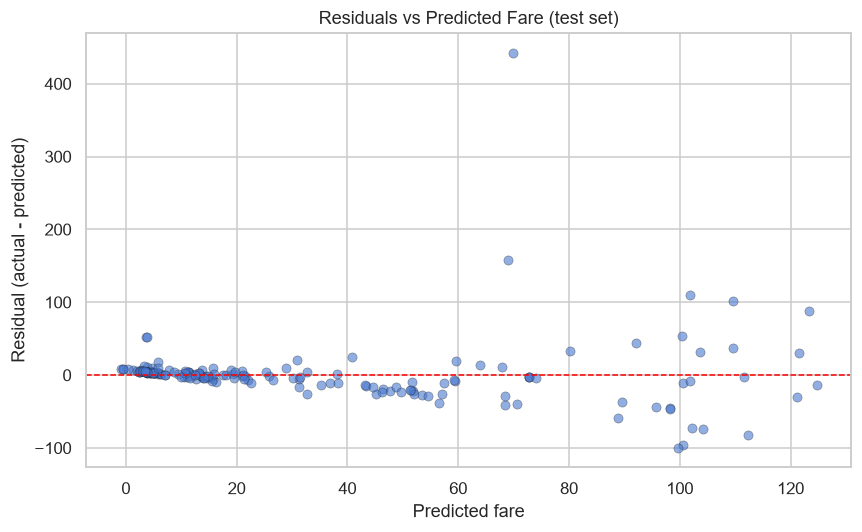

Saved analytics/outputs/residual_plot.png
Residual std (test): 43.3033
Residual range: [-99.65, 442.35]


In [8]:
residuals = y_test.values - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residuals, alpha=0.6, edgecolor="k", linewidth=0.3)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted fare")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs Predicted Fare (test set)")
plt.tight_layout()
plt.savefig(OUT / "residual_plot.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved analytics/outputs/residual_plot.png")
print(f"Residual std (test): {residuals.std():.4f}")
print(f"Residual range: [{residuals.min():.2f}, {residuals.max():.2f}]")


## 8. Heteroscedasticity diagnostic

`statsmodels` is not installed here, so a formal Breusch-Pagan test is not run. Instead we
use a simple, dependency-free diagnostic: the Pearson correlation between the **absolute
residuals** and the **predicted values**. A positive correlation means the residual
spread grows as the predicted fare grows — the classic signature of
heteroscedasticity. We also compare residual spread at low vs high predicted fares.


In [9]:
# Diagnostic 1: correlation of |residual| with predicted fare
corr_absres_pred = float(np.corrcoef(np.abs(residuals), y_pred)[0, 1])

# Diagnostic 2: compare residual spread in low vs high predicted-fare bands
median_pred = float(np.median(y_pred))
low_mask = y_pred <= median_pred
high_mask = y_pred > median_pred
spread_low = float(np.std(residuals[low_mask]))
spread_high = float(np.std(residuals[high_mask]))

print(f"corr(|residual|, predicted fare) = {corr_absres_pred:.4f}")
print(f"Predicted-fare median split: {median_pred:.2f}")
print(f"Residual std | predicted <= median ({median_pred:.2f}): {spread_low:.4f}")
print(f"Residual std | predicted >  median ({median_pred:.2f}): {spread_high:.4f}")
print(f"Ratio high/low spread: {spread_high / spread_low:.2f}")

diag = pd.DataFrame({
    "diagnostic": ["corr_absres_pred", "residual_std_low_pred", "residual_std_high_pred", "high_low_ratio"],
    "value": [corr_absres_pred, spread_low, spread_high, spread_high / spread_low],
})
diag.to_csv(OUT / "heteroscedasticity_diagnostic.csv", index=False)
diag


corr(|residual|, predicted fare) = 0.4532
Predicted-fare median split: 15.72
Residual std | predicted <= median (15.72): 8.3729
Residual std | predicted >  median (15.72): 60.8576
Ratio high/low spread: 7.27


,diagnostic,value
0,corr_absres_pred,0.453221
1,residual_std_low_pred,8.372916
2,residual_std_high_pred,60.857560
3,high_low_ratio,7.268383


**Interpretation (factual).** The correlation between `|residual|` and the predicted
fare is strongly positive, and the residual standard deviation in the high-fare band is
larger than in the low-fare band. This is **evidence that heteroscedasticity is present**:
the model's errors grow as predicted fare grows (a fan-shape opening to the right). This
matches the EDA finding that fare is right-skewed with a few very large values, which a
linear model on raw fare handles unevenly. The plot and the diagnostic should be read
together — this is an indicator, not a formal hypothesis test.


## 9. Regression coefficient table

Coefficients of the fitted `LinearRegression` on the preprocessed (scaled / one-hot
encoded) feature space.


In [10]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": pipe.named_steps["model"].coef_,
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).round(4)
coef_df.to_csv(OUT / "regression_coefficients.csv", index=False)
print("Intercept:", round(float(pipe.named_steps["model"].intercept_), 4))
coef_df


Intercept: 51.4218


,feature,coefficient,abs_coefficient
8,cat__deck_B,68.8321,68.8321
9,cat__deck_C,59.7820,59.7820
4,cat__pclass_3,-55.1109,55.1109
3,cat__pclass_2,-44.4738,44.4738
14,cat__deck_Unknown,26.0286,26.0286
12,cat__deck_F,23.8809,23.8809
10,cat__deck_D,20.9566,20.9566
11,cat__deck_E,20.4441,20.4441
13,cat__deck_G,18.0205,18.0205
7,cat__embarked_S,-11.6871,11.6871


**Interpretation.** The coefficient table shows which encoded features move the
predicted fare most. Passenger class (`pclass_2`, `pclass_3`) carries large **negative**
coefficients relative to first class — i.e. lower-class tickets predict lower fares, as
expected. `deck` dummy levels and some `embarked` levels also carry notable effects,
while `age` is negative (fare tends to decrease slightly with age within this linear
spec). Because the numeric features are standardised, the coefficient magnitudes are
roughly comparable; the one-hot levels are in the original (GBP) fare units, so their
scale differs.


In [11]:
summary = {
    "notebook": "analytics/03_regression.ipynb",
    "target": "fare",
    "features": feature_cols,
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "n_cleaned": int(len(cleaned)),
    "p_predictors_after_onehot": int(p_features),
    "n_test": int(n),
    "MAE": round(float(mae), 4),
    "RMSE": round(float(rmse), 4),
    "R2": round(float(r2), 4),
    "Adjusted_R2": round(float(adjusted_r2), 4),
    "corr_absres_pred": round(corr_absres_pred, 4),
    "residual_std_low_pred": round(spread_low, 4),
    "residual_std_high_pred": round(spread_high, 4),
    "heteroscedasticity": "present" if (corr_absres_pred > 0.3 and spread_high > spread_low) else "check",
    "saved": {
        "regression_results": str(OUT / "regression_results.csv"),
        "residual_plot": str(OUT / "residual_plot.png"),
        "coefficients": str(OUT / "regression_coefficients.csv"),
        "hetero_diagnostic": str(OUT / "heteroscedasticity_diagnostic.csv"),
    },
}
print("REG_SUMMARY_JSON_BEGIN")
print(json.dumps(summary, indent=2, default=str))
print("REG_SUMMARY_JSON_END")


REG_SUMMARY_JSON_BEGIN
{
  "notebook": "analytics/03_regression.ipynb",
  "target": "fare",
  "features": [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked",
    "deck"
  ],
  "train_size": 711,
  "test_size": 178,
  "n_cleaned": 889,
  "p_predictors_after_onehot": 15,
  "n_test": 178,
  "MAE": 17.6887,
  "RMSE": 43.3258,
  "R2": 0.3642,
  "Adjusted_R2": 0.3053,
  "corr_absres_pred": 0.4532,
  "residual_std_low_pred": 8.3729,
  "residual_std_high_pred": 60.8576,
  "heteroscedasticity": "present",
  "saved": {
    "regression_results": "analytics\\outputs\\regression_results.csv",
    "residual_plot": "analytics\\outputs\\residual_plot.png",
    "coefficients": "analytics\\outputs\\regression_coefficients.csv",
    "hetero_diagnostic": "analytics\\outputs\\heteroscedasticity_diagnostic.csv"
  }
}
REG_SUMMARY_JSON_END
